# Dactyloscopy → AnnData

The Dactyloscopy screen ([`cpg0025`](https://broadinstitute.github.io/cellpainting-gallery/)), five cell lines across seventeen plates. Only `backend/` is published; its `_normalized.csv` files are well-level profiles and total 276 MB, not the 45 GB the full backend suggests.

One observation is a well, one variable is a CellProfiler feature.
Well-level profiles only, no images:

```bash
aws s3 cp --no-sign-request --recursive --exclude "*" --include "*_normalized.csv" \
  s3://cellpainting-gallery/cpg0025-dactyloscopy/broad/workspace/backend/ .
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/cpg0025-dactyloscopy/profiles").expanduser()

In [2]:
files = sorted(PROFILES.glob("*/*/*.csv"))
print(f"{len(files)} plates")

17 plates


In [3]:
adata = cpio.read_profiles(
    files, index_columns=["batch", "Plate", "Well"], path_columns={"batch": 2}, on_column_mismatch="intersect"
)
adata

/home/lheumos/code/cell-painting-io/cell_painting_io.py:31: DtypeWarning: Columns (0: Metadata_solvent, 1: Metadata_pert_vehicle) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


AnnData object with n_obs × n_vars = 6420 × 2200
    obs: 'Plate', 'Well', 'Assay_Plate_Barcode', 'Plate_Map_Name', 'well_position', 'cell_line', 'time_point', 'broad_sample', 'mg_per_ml', 'mmoles_per_liter', 'volume_ul', 'amount_mg', 'pert_name', 'solvent', 'pert_id', 'pert_mfc_id', 'pert_well', 'pert_id_vendor', 'cell_id', 'broad_sample_type', 'pert_vehicle', 'pert_type', 'pert_iname', 'moa', 'pert_mfc_desc', 'batch'
    layers: None (.X)

In [4]:
cpio.annotate_features(adata.var)
adata = cpio.drop_incomplete_features(adata)
adata = cpio.drop_extreme_features(adata)
adata = cpio.drop_constant_features(adata)


def present(columns):
    return [c for c in columns if c in adata.obs.columns and adata.obs[c].nunique() > 1]


cpio.categorize(adata, present(["Plate", "cell_line", "solvent", "broad_sample_type", "moa", "pert_type"]))
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Cells_AreaShape_Area,cells,areashape,NaN,NaN,0
Cells_AreaShape_Center_X,cells,areashape,NaN,NaN,0
Cells_AreaShape_Center_Y,cells,areashape,NaN,NaN,0
Cells_AreaShape_Compactness,cells,areashape,NaN,NaN,0
Cells_AreaShape_Eccentricity,cells,areashape,NaN,NaN,0
...,...,...,...,...,...
Nuclei_Texture_Variance_Mito_20_0,nuclei,texture,mito,NaN,1
Nuclei_Texture_Variance_Mito_5_0,nuclei,texture,mito,NaN,1
Nuclei_Texture_Variance_RNA_10_0,nuclei,texture,rna,NaN,1


## Sanity checks

In [5]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features")
print(f"non-finite: {int((~np.isfinite(adata.X)).sum())} | max|x|: {np.abs(adata.X).max():.1f}")
for column in present(["cell_line", "moa", "pert_type"]):
    print(f"\n{column}:")
    print(adata.obs[column].value_counts(dropna=False).head(6).to_string())

6,420 wells x 2,121 features
non-finite: 0 | max|x|: 470110.5

cell_line:
cell_line
MCF7         2110
A549         2103
MCF7_A549    1919
XC.L10        192
A549_MCF7      96

moa:
moa
<NA>                           4845
Aurora kinase inhibitor         135
CDK inhibitor                    90
Insulin sensitizer               90
KIT inhibitor                    90
Phosphodiesterase inhibitor      90

pert_type:
pert_type
trt        5392
control    1028


In [6]:
adata.write_h5ad(PROFILES.parent / "dactyloscopy.h5ad")

## UMAP

The profiles are already normalized, so they enter PCA unscaled.

In [7]:
sc.pp.pca(adata, n_comps=min(50, adata.n_vars - 1))
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


How often do neighbouring wells share a label, against the rate expected if labels were shuffled?
Above 1 means the covariate explains part of the embedding.

In [8]:
cpio.neighbour_enrichment(adata, present(["Plate", "cell_line", "moa", "pert_type"]))

,observed,baseline,ratio
covariate,,,
Plate,0.291,0.059,4.934
cell_line,0.649,0.306,2.124
moa,0.330,0.042,7.934
pert_type,0.854,0.731,1.168


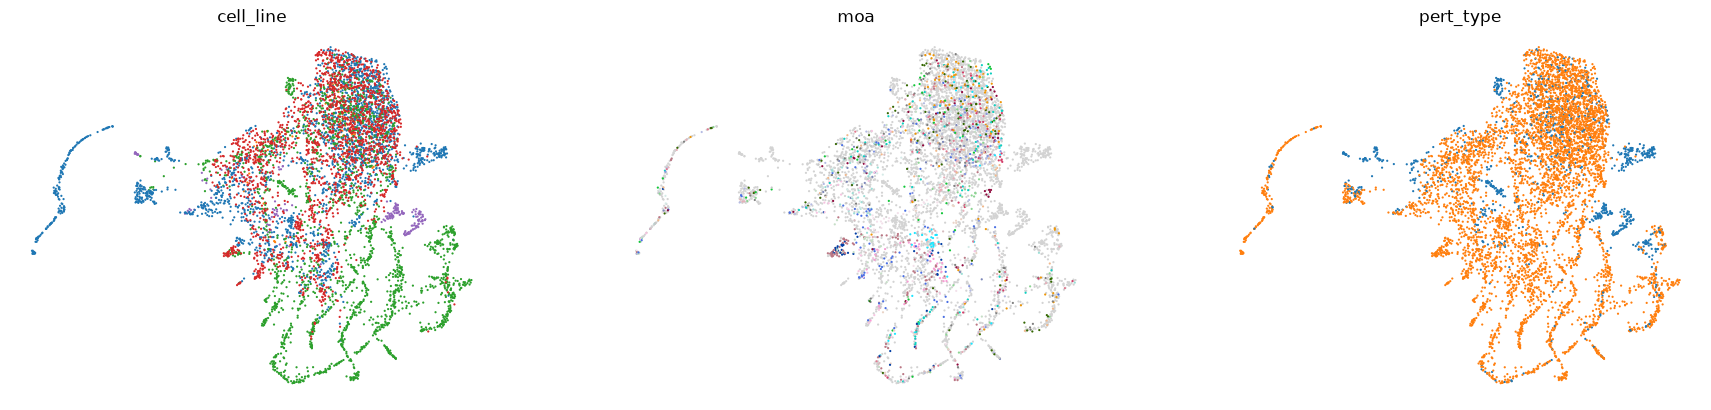

In [9]:
colours = present(["cell_line", "moa", "pert_type"])[:3] or None
crowded = bool(colours) and max(adata.obs[c].nunique() for c in colours) > 20
sc.pl.umap(adata, color=colours, ncols=3, frameon=False, size=10, legend_loc="none" if crowded else "right margin")